# Gene-expression programs and the copy-number confound

Beyond copy number, malignant cells run **gene-expression programs** — coordinated modules
(proliferation, EMT, hypoxia, …) that a factor model (NMF, cNMF, scDEF) tries to recover from scRNA.
iscc's R13 program layer plants a **known** loading matrix, so we can score recovery — and expose the
central confound:

> **CNAs are contiguous; programs are scattered.** A copy-number gain co-regulates a whole *genomic
> segment* of genes at once, which a factor model can absorb as a spurious "program". A real program's
> genes are **scattered across the genome**. The statistic that separates them is exactly that —
> whether a factor's top genes are **positionally clustered** (a CNA artefact) or **scattered** (a
> program).

And a real scRNA study sees **all cell types**, so a factor model must *also* separate **cell-type
identity** (malignant vs microenvironment) from **within-malignant programs**. We analyse the mixture
throughout.

> The full tool benchmark (scDEF / cNMF, and how recovery degrades with CNA burden) is
> `validation/validate_programs.py`.

In [1]:
%matplotlib inline
import os, sys
sys.path.insert(0, os.path.abspath("."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import base_sim as B
import programs_common as PC      # positional_clustering / scattered_null diagnostics
from iscc.data import scRNA

## 1. Grow the tumour and assay the mixture

The shared substrate has the program layer on. We assay a realistic-purity mixture and keep the true
per-cell program activities (`cell_program`) and the true loading (`program_truth`) to score against.

In [2]:
t = B.grow_base_tumor()
cd = t.cell_data
types = B.cell_types(t)
idx = np.asarray(cd["cell_type"].index)
is_cancer = types == "cancer"

pt = t.program_truth
loading = np.asarray(pt["loading"])            # K_programs x genes
prog_names = list(pt["program_names"])
K = len(prog_names)
seg_sizes = np.asarray(t.selection.segment_sizes)
print(f"{K} planted programs: {prog_names}")
print(f"loading matrix: {loading.shape} (programs x genes)")

rng = np.random.default_rng(0)
cancer_cells = list(rng.choice(idx[is_cancer], size=500, replace=False))
normal_cells = list(rng.choice(idx[np.isin(types, ("epithelial", "stromal"))], size=350, replace=False))
mixture = cancer_cells + normal_cells
pos = {c: i for i, c in enumerate(idx)}
mix_pos = np.array([pos[c] for c in mixture])
is_mal_mix = np.isin(mixture, cancer_cells)
print(f"assayed mixture: {len(mixture)} cells | purity {is_mal_mix.mean():.0%}")

6 planted programs: ['proliferation', 'emt', 'hypoxia', 'drug_resistance', 'immune_evasion', 'program_5']
loading matrix: (6, 600) (programs x genes)
assayed mixture: 850 cells | purity 59%


## 2. Programs track their drivers — genotype **and** niche

A program is not decoration — in iscc each is **coupled to a phenotype or a niche field**, so its
activity has a *reason*. The flagship coupling on the ductal field is the invasive **`emt`** program,
driven by **two** sources at once:

* **`emt` ← `breach` (the genetic arm)** — the heritable invasion trait raises the invasive program;
* **`emt` ← epithelial fraction (the niche arm)** — a cell at a gland wall expresses more `emt` than one
  in open stroma, *regardless of its genotype*.

That second arm is the **genetic-vs-niche confound**: below, `emt` still rises with the epithelial
fraction of a cell's niche **after** removing each clone's own mean (the genotype-controlled *partial*
correlation) — so invasive expression ≠ invasive genotype. (The full treatment is
[`compartment_selection_confound`](compartment_selection_confound.ipynb).) The **proliferation** program
tracks the **division rate**, but only *weakly* here — division's fold-change saturates at
`max_birth_rate`, so with the modest per-phenotype gain its signal sits close to the activity noise (an
honest reminder that a program–driver link can be faint).

proliferation~division r=0.10 (weak, division gain 0.5) | emt~breach r=0.35 (genetic arm) | emt~epithelial raw r=0.73, genotype-controlled r=0.38 (niche arm / confound)


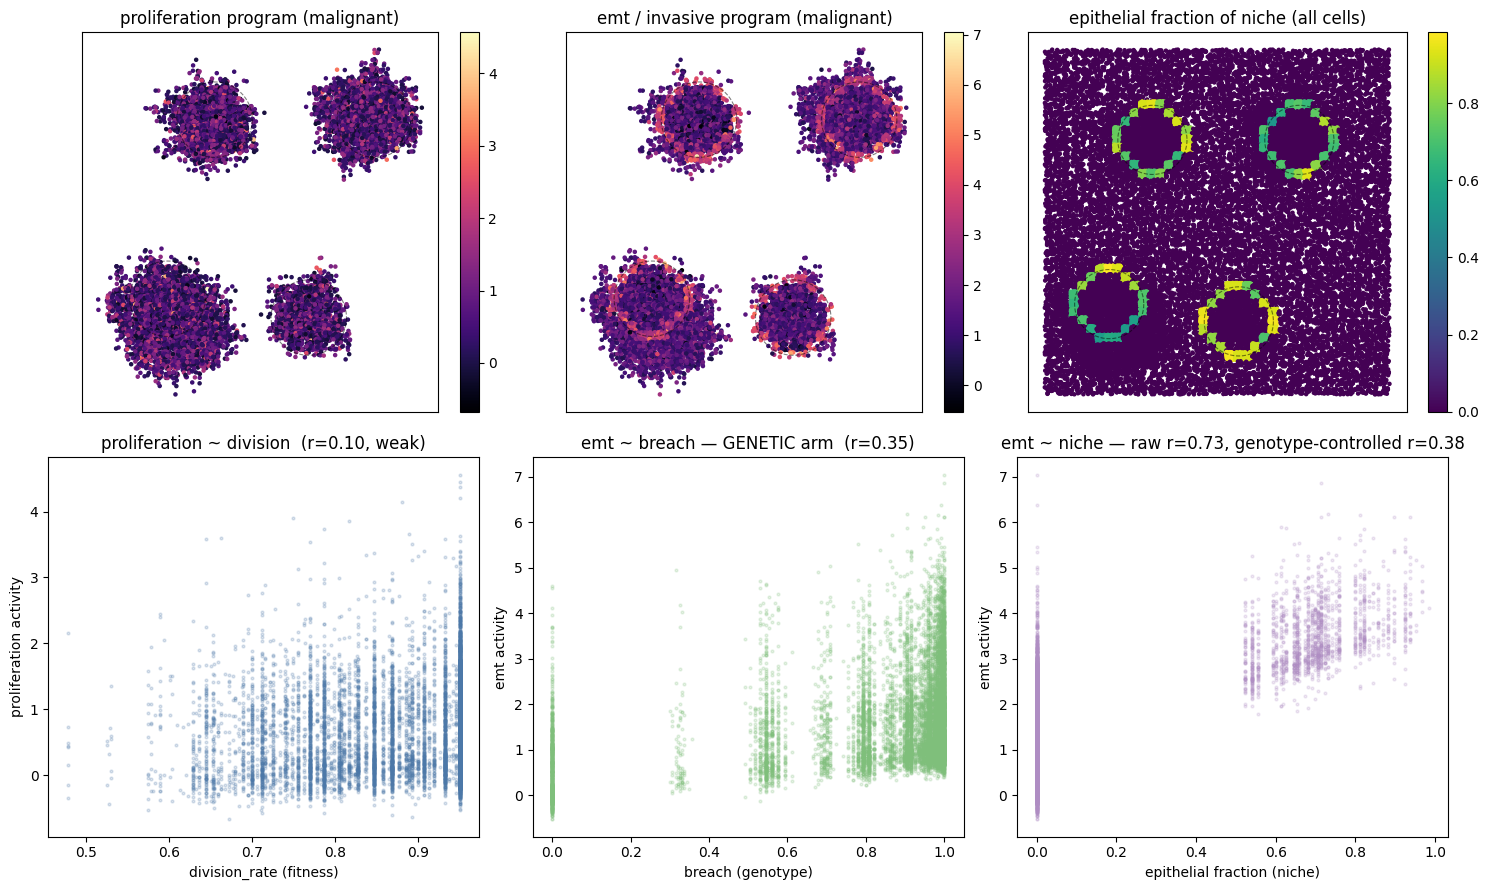

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.45, 0.45, len(crd))
jy = crd["row"].values + jit.uniform(-0.45, 0.45, len(crd))

div    = B.cell_rate(t, "division_rate")
breach = B.cell_trait(t, "breach")
prol   = B.cell_program(t, "proliferation")
emt    = B.cell_program(t, "emt")
epi    = B.cell_epithelial_fraction(t)          # the niche arm

cp = cd["cell_program"].values                  # cells x K; dominant program per cancer cell (used in §4)
dom = np.full(len(idx), -1)
dom[is_cancer] = cp[is_cancer].argmax(1)

def _corr(a, b):
    ok = is_cancer & np.isfinite(a) & np.isfinite(b)
    return float(np.corrcoef(a[ok], b[ok])[0, 1]) if ok.sum() > 3 and a[ok].std() > 0 and b[ok].std() > 0 else float("nan")

# emt ~ epithelial niche, controlling for genotype (partial correlation) — the confound
gid = cd["cell_type"]["cell_id"].values
emt_c, epi_c, gid_c = emt[is_cancer].astype(float), epi[is_cancer], gid[is_cancer]
resid = emt_c.copy()
for g in np.unique(gid_c):
    mm = gid_c == g; resid[mm] = emt_c[mm] - emt_c[mm].mean()
r_partial = float(np.corrcoef(resid, epi_c)[0, 1])
r_prol, r_emt_br, r_emt_epi = _corr(prol, div), _corr(emt, breach), _corr(emt, epi)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
def spatial(a, val, title, mask=None, cmap="magma"):
    m = (is_cancer if mask is None else mask) & np.isfinite(val)
    sc = a.scatter(jx[m], jy[m], s=5, c=val[m], cmap=cmap)
    B.draw_glands(a, t); a.set_aspect("equal"); a.invert_yaxis()
    a.set_xticks([]); a.set_yticks([]); a.set_title(title); plt.colorbar(sc, ax=a, fraction=0.046)
spatial(ax[0, 0], prol, "proliferation program (malignant)")
spatial(ax[0, 1], emt,  "emt / invasive program (malignant)")
spatial(ax[0, 2], epi,  "epithelial fraction of niche (all cells)", mask=np.ones(len(idx), bool), cmap="viridis")

ax[1, 0].scatter(div[is_cancer], prol[is_cancer], s=4, alpha=0.2, color="#4c78a8")
ax[1, 0].set_xlabel("division_rate (fitness)"); ax[1, 0].set_ylabel("proliferation activity")
ax[1, 0].set_title(f"proliferation ~ division  (r={r_prol:.2f}, weak)")
ax[1, 1].scatter(breach[is_cancer], emt[is_cancer], s=4, alpha=0.2, color="#7fbf7b")
ax[1, 1].set_xlabel("breach (genotype)"); ax[1, 1].set_ylabel("emt activity")
ax[1, 1].set_title(f"emt ~ breach — GENETIC arm  (r={r_emt_br:.2f})")
ax[1, 2].scatter(epi[is_cancer], emt[is_cancer], s=4, alpha=0.2, color="#af8dc3")
ax[1, 2].set_xlabel("epithelial fraction (niche)"); ax[1, 2].set_ylabel("emt activity")
ax[1, 2].set_title(f"emt ~ niche — raw r={r_emt_epi:.2f}, genotype-controlled r={r_partial:.2f}")
plt.tight_layout()
print(f"proliferation~division r={r_prol:.2f} (weak, division gain 0.5) | "
      f"emt~breach r={r_emt_br:.2f} (genetic arm) | "
      f"emt~epithelial raw r={r_emt_epi:.2f}, genotype-controlled r={r_partial:.2f} (niche arm / confound)")

## 3. The true loading — programs are scattered

A program's genes are spread **across the genome**, not packed into one segment. Tallying program 0's
top genes by genomic segment shows them scattered across all chromosomes — the defining contrast with a
copy-number event, which would land entirely in one segment.

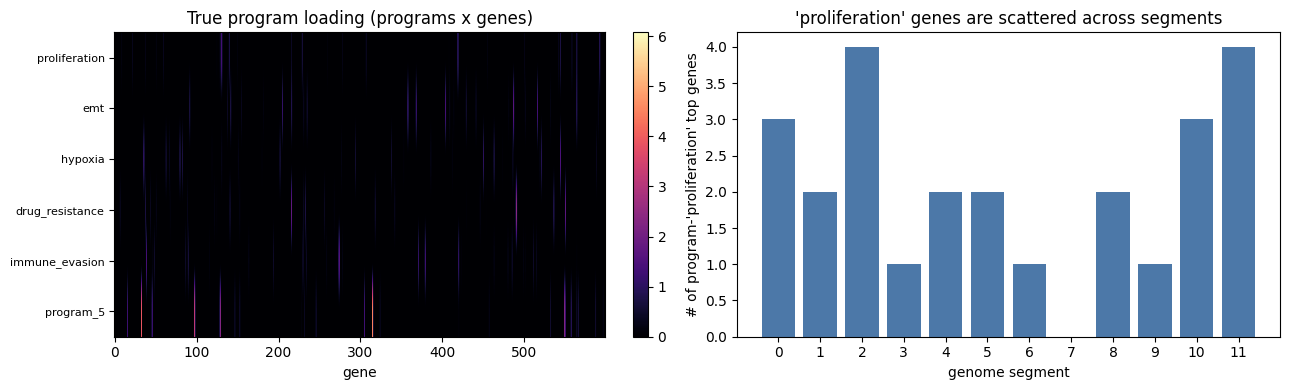

In [4]:
offs = np.concatenate([[0], np.cumsum(seg_sizes)]).astype(int)
def seg_of(gene_ix):
    return np.searchsorted(offs, gene_ix, side="right") - 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(loading, aspect="auto", cmap="magma")
axes[0].set_yticks(range(K)); axes[0].set_yticklabels(prog_names, fontsize=8)
axes[0].set_xlabel("gene"); axes[0].set_title("True program loading (programs x genes)")
plt.colorbar(im, ax=axes[0], fraction=0.046)

top0 = np.argsort(loading[0])[::-1][:25]
seg_counts = np.bincount(seg_of(top0), minlength=len(seg_sizes))
axes[1].bar(range(len(seg_sizes)), seg_counts, color="#4c78a8")
axes[1].set_xlabel("genome segment"); axes[1].set_ylabel(f"# of program-'{prog_names[0]}' top genes")
axes[1].set_title(f"'{prog_names[0]}' genes are scattered across segments")
axes[1].set_xticks(range(len(seg_sizes)))
plt.tight_layout()

## 4. The mixture: cell-type identity vs within-malignant programs

Embedding the mixture (PCA of the scRNA counts), the **first** axis of variation is cell-type identity
— malignant vs microenvironment separate cleanly. The programs live *within* the malignant cloud. A
factor model must recover both levels: one factor for the cell-type split, and the rest for the
programs.

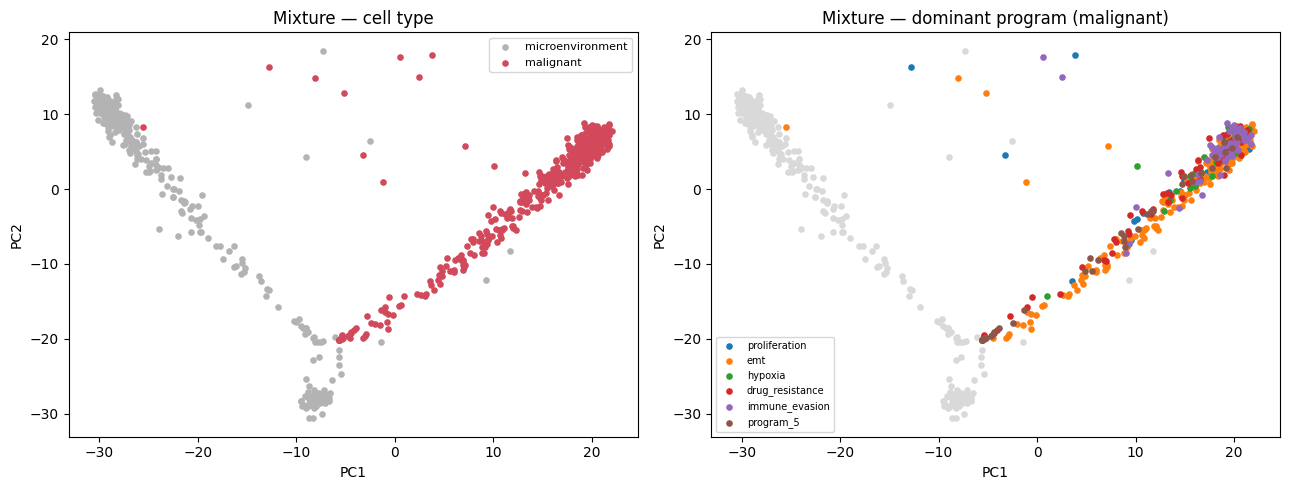

In [5]:
from sklearn.decomposition import PCA

rna = scRNA(n_cells=len(mixture), protocol="10x", seed=1).run(cd, cell_subset=mixture)
Y = rna.observed_counts
rna_cells = list(Y.index)
is_mal = np.isin(rna_cells, cancer_cells)
Yv = Y.values.astype(float)
Ycpm = Yv / np.where(Yv.sum(1, keepdims=True) > 0, Yv.sum(1, keepdims=True), 1) * 1e4
Ylog = np.log1p(Ycpm)
pcs = PCA(n_components=10, random_state=0).fit_transform(Ylog - Ylog.mean(0))

dom_mix = np.array([dom[pos[c]] for c in rna_cells])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pcs[~is_mal, 0], pcs[~is_mal, 1], s=14, c="0.7", label="microenvironment")
axes[0].scatter(pcs[is_mal, 0], pcs[is_mal, 1], s=14, c="#d1495b", label="malignant")
axes[0].legend(fontsize=8); axes[0].set_title("Mixture — cell type")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
cmap = plt.get_cmap("tab10")
axes[1].scatter(pcs[~is_mal, 0], pcs[~is_mal, 1], s=14, c="0.85")
for k in range(K):
    m = is_mal & (dom_mix == k)
    axes[1].scatter(pcs[m, 0], pcs[m, 1], s=14, color=cmap(k), label=prog_names[k])
axes[1].legend(fontsize=7); axes[1].set_title("Mixture — dominant program (malignant)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()

## 5. The diagnostic: positional clustering

`positional_clustering` takes a factor's top genes and returns the largest fraction landing in any one
segment. A genuine program sits near the **scattered null** (dashed band, estimated by random gene
sets); a factor that has absorbed a copy-number segment approaches **1.0**. Below: every true program
scores near the null, while a synthetic "pseudo-factor" made of one contiguous CNA segment pins at 1.0.

scattered null: mean 0.18, 95% 0.24
true programs: [0.16, 0.2, 0.16, 0.12, 0.16, 0.24]   |  CNA pseudo-factor: 1.00


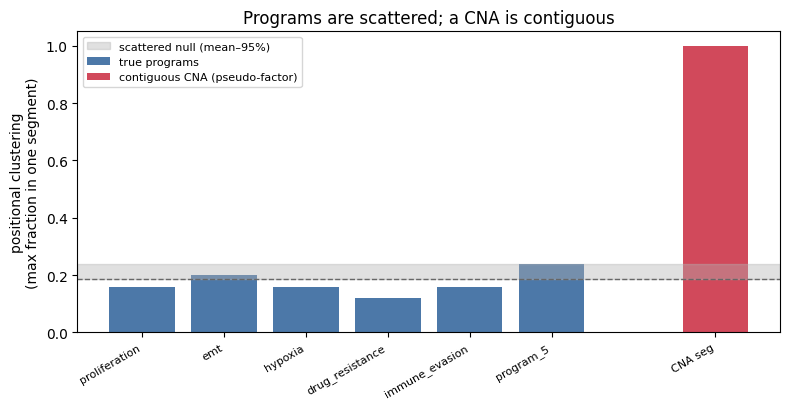

In [6]:
null_mean, null_95 = PC.scattered_null(seg_sizes, top_n=25)
prog_clust = [PC.positional_clustering(loading[k], seg_sizes, top_n=25) for k in range(K)]
# a pseudo-factor that is exactly one contiguous copy-number segment
pseudo = np.zeros(loading.shape[1]); pseudo[offs[3]:offs[4]] = 1.0
pseudo_clust = PC.positional_clustering(pseudo, seg_sizes, top_n=25)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(K), prog_clust, color="#4c78a8", label="true programs")
ax.bar([K + 1], [pseudo_clust], color="#d1495b", label="contiguous CNA (pseudo-factor)")
ax.axhspan(null_mean, null_95, color="0.7", alpha=0.4, label="scattered null (mean–95%)")
ax.axhline(null_mean, color="0.4", ls="--", lw=1)
ax.set_xticks(list(range(K)) + [K + 1])
ax.set_xticklabels(prog_names + ["CNA seg"], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("positional clustering\n(max fraction in one segment)")
ax.set_title("Programs are scattered; a CNA is contiguous")
ax.legend(fontsize=8)
plt.tight_layout()
print(f"scattered null: mean {null_mean:.2f}, 95% {null_95:.2f}")
print(f"true programs: {np.round(prog_clust,2).tolist()}   |  CNA pseudo-factor: {pseudo_clust:.2f}")

## 6. Self-contained recovery: NMF on the mixture

A plain NMF on the **log-normalised** mixture counts (given room for the cell-type factor) recovers the
**stronger** programs — Hungarian-matching each true program to its best NMF factor gives a good cosine
for several of them — while the **weakest** programs (a barely-active one like `immune_evasion`, and the
subtler modules) stay confounded by the dominant cell-type and CNA structure. This is the honest limit
of an off-the-shelf factorisation, and exactly why the dedicated tools (scDEF / cNMF, with hierarchical /
consensus priors) exist. Reassuringly, whatever it *does* recover is **scattered** (near the null), not a
copy-number segment; one extra factor separates the microenvironment.

per-program recovery (true program -> best NMF factor):
  proliferation    cosine 0.11   positional-clustering 0.16
  emt              cosine 0.79   positional-clustering 0.16
  hypoxia          cosine 0.13   positional-clustering 0.20
  drug_resistance  cosine 0.87   positional-clustering 0.20
  immune_evasion   cosine 0.16   positional-clustering 0.20
  program_5        cosine 0.62   positional-clustering 0.20

mean matched cosine: 0.45  (log-normalised NMF; the stronger programs recover, the weakest do not)
cell-type factor (separates normal vs malignant): factor 5


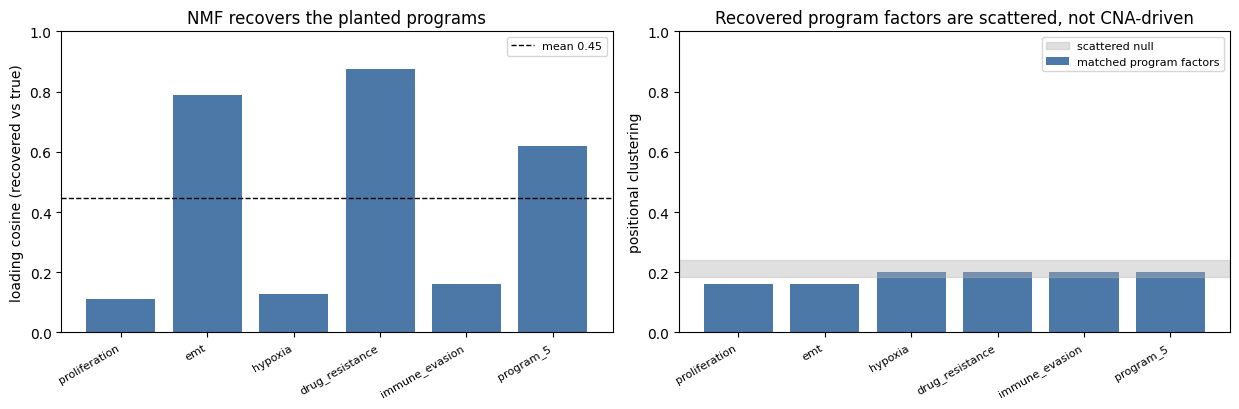

In [7]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else float(a @ b / (na * nb))

# NMF on the LOG-normalised counts (log1p CPM) — a standard scRNA preprocessing step that lifts recovery
# over raw CPM by damping the few very-high-count genes that otherwise dominate the factorisation.
nmf = NMF(n_components=K + 2, init="nndsvda", max_iter=600, random_state=0)
Wcell = nmf.fit_transform(Ylog)                # cells x factors  (Ylog = log1p(CPM), from §4)
Hfac = nmf.components_                          # factors x genes

C = np.array([[cosine(loading[i], Hfac[j]) for j in range(Hfac.shape[0])] for i in range(K)])
rows, cols = linear_sum_assignment(-C)
matched_cos = C[rows, cols]
# which factor best marks the microenvironment? the one whose activity most separates normal vs malig
sep = [abs(Wcell[is_mal, j].mean() - Wcell[~is_mal, j].mean()) / (Wcell[:, j].std() + 1e-9)
       for j in range(Hfac.shape[0])]
celltype_factor = int(np.argmax(sep))
matched_clust = [PC.positional_clustering(Hfac[j], seg_sizes, 25) for j in cols]

print("per-program recovery (true program -> best NMF factor):")
for i, j, cc in zip(rows, cols, matched_cos):
    print(f"  {prog_names[i]:<16s} cosine {cc:.2f}   positional-clustering {PC.positional_clustering(Hfac[j], seg_sizes,25):.2f}")
print(f"\nmean matched cosine: {matched_cos.mean():.2f}  (log-normalised NMF; the stronger programs recover, the weakest do not)")
print(f"cell-type factor (separates normal vs malignant): factor {celltype_factor}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].bar(range(K), matched_cos, color="#4c78a8")
axes[0].axhline(matched_cos.mean(), color="k", ls="--", lw=1, label=f"mean {matched_cos.mean():.2f}")
axes[0].set_xticks(range(K)); axes[0].set_xticklabels(prog_names, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("loading cosine (recovered vs true)"); axes[0].set_ylim(0, 1)
axes[0].set_title("NMF recovers the planted programs"); axes[0].legend(fontsize=8)

axes[1].bar(range(K), matched_clust, color="#4c78a8", label="matched program factors")
axes[1].axhspan(null_mean, null_95, color="0.7", alpha=0.4, label="scattered null")
axes[1].set_xticks(range(K)); axes[1].set_xticklabels(prog_names, rotation=30, ha="right", fontsize=8)
axes[1].set_ylabel("positional clustering"); axes[1].set_ylim(0, 1)
axes[1].set_title("Recovered program factors are scattered, not CNA-driven")
axes[1].legend(fontsize=8)
plt.tight_layout()

## What this shows

* Each program **has a driver** — the invasive `emt` program tracks **both** its genetic driver
  (`breach`) **and** its niche (the epithelial interface), so invasive expression is confounded by
  location (a positive genotype-controlled partial correlation); proliferation tracks division only
  weakly. The expression layer is a readout of the underlying evolutionary/microenvironmental state.
* iscc plants **known** gene-expression programs (`program_truth`), so program recovery is scorable —
  ground truth no real scRNA dataset provides.
* The programs are **scattered across the genome**, the defining contrast with a **contiguous** copy-
  number event; `positional_clustering` (vs the scattered null) is the statistic that tells a real
  program from a CNA dressed up as one.
* A self-contained **NMF on the mixture** recovers the stronger programs (and whatever it recovers is
  scattered, not CNA-driven) while a separate factor absorbs the microenvironment — an honest floor,
  well below what the dedicated tools (scDEF / cNMF) achieve, on the emergent signal they exploit.

**Next / see also:**
[`base_simulation`](base_simulation.ipynb) ·
[`compartment_selection_confound`](compartment_selection_confound.ipynb) (the full genetic-vs-niche
confound) · [`cohort_shared_programs`](cohort_shared_programs.ipynb) (recovering the *same* programs
across a 5-patient cohort) · `validation/validate_programs.py` (the scDEF / cNMF benchmark).